# 1. Getting started: an explainable classifier in five minutes

Ex-Fuzzy learns **fuzzy rule bases**: small sets of rules such as
*IF petal length IS Low THEN setosa*, where "Low" is a fuzzy set with a
membership function rather than a hard threshold. A genetic algorithm
searches for the rules; the result is a model you can read.

This notebook trains one classifier on the Iris data and shows the parts
you will use most: fitting, scoring, reading the rules, probabilities,
per-sample explanations, and the plots of the fuzzy partitions.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from ex_fuzzy import BaseFuzzyRulesClassifier, eval_tools, fuzzy_sets as fs, rules, utils, vis_rules

iris = load_iris(as_frame=True)
X = iris.frame.drop(columns='target')
y = iris.target_names[iris.target]          # string labels work directly

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0, stratify=y)
X_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
14,5.8,4.0,1.2,0.2
148,6.2,3.4,5.4,2.3
62,6.0,2.2,4.0,1.0
26,5.0,3.4,1.6,0.4
28,5.2,3.4,1.4,0.2


## Fuzzy partitions

Every input variable is split into a few overlapping fuzzy sets, its
*linguistic labels* (Low, Medium, High). `construct_partitions` builds them
from the quantiles of the training data. You can also let the genetic search
optimise the partitions (notebook 3), but fixed partitions are faster to fit
and easier to explain, so they are the default choice.

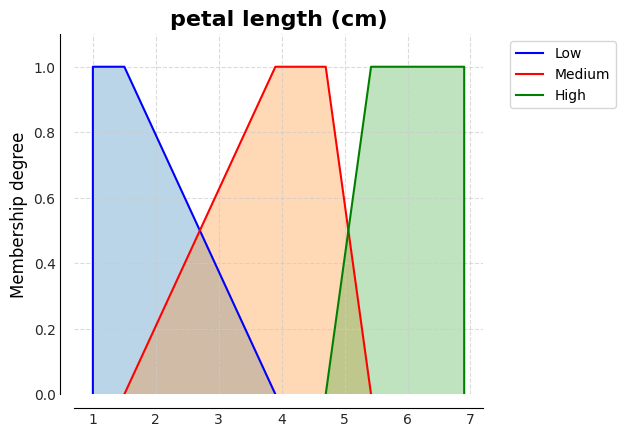

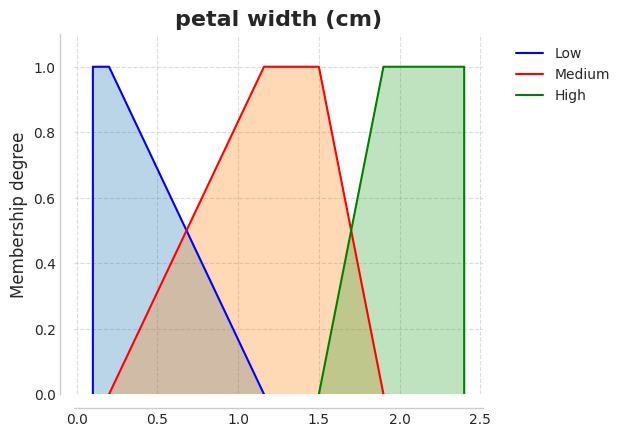

In [2]:
partitions = utils.construct_partitions(X_train, fs.FUZZY_SETS.t1)
for variable in partitions[2:]:               # petal length and petal width
    vis_rules.plot_fuzzy_variable(variable)

## Fitting

The classifier follows the scikit-learn conventions: parameters in the
constructor, `fit`, `predict`, `score`, `classes_`. `nRules` caps the number
of rules and `nAnts` the number of conditions per rule; both are upper
bounds, the search may use fewer. The search budget (`n_gen`, `pop_size`)
and its seed live in the constructor too, and early stopping is on by
default (`patience=10`).

In [3]:
classifier = BaseFuzzyRulesClassifier(
    nRules=10, nAnts=3, linguistic_variables=partitions,
    n_gen=30, pop_size=30, random_state=0,
)
classifier.fit(X_train, y_train)

print(f'train accuracy: {classifier.score(X_train, y_train):.3f}')
print(f'test accuracy:  {classifier.score(X_test, y_test):.3f}')
print(f'generations run: {classifier.n_generations_run_} (stopped early: {classifier.stopped_early_})')
print('classes:', classifier.classes_)

train accuracy: 0.830
test accuracy:  0.800
generations run: 11 (stopped early: True)
classes: ['setosa' 'versicolor' 'virginica']


## Reading the rules

Each rule ends with its statistics on the training data:

- **DS**, the dominance score, is support times confidence: how often the
  rule fires for its class and how exclusively. It weights the rule during
  inference.
- **ACC** is the accuracy of the rule on the samples where it was the
  strongest rule.

A sample is classified by the rule with the highest *association degree*,
the product of its firing strength and its dominance score.

In [4]:
classifier.print_rules()

Rules for consequent: setosa
----------------
IF sepal length (cm) IS Medium AND petal width (cm) IS High WITH DS 0.0, ACC 0.717391304347826

Rules for consequent: versicolor
----------------
IF sepal width (cm) IS Low WITH DS 0.1008333333333333, ACC 0.9

Rules for consequent: virginica
----------------
IF petal width (cm) IS High WITH DS 0.2830081300813008, ACC 0.9411764705882353




## Probabilities and per-sample explanations

`predict_proba` normalises the strongest association degree of each class.
`explainable_predict` returns, for every sample, the winning rule and its
association degree, so a prediction can always be traced to one rule.

In [5]:
pd.DataFrame(classifier.predict_proba(X_test.head()), columns=classifier.classes_, index=X_test.head().index).round(3)

,setosa,versicolor,virginica
142,0.000,0.263,0.737
12,0.333,0.333,0.333
147,0.000,0.000,1.000
39,0.333,0.333,0.333
136,0.000,0.000,1.000


In [6]:
explained = classifier.explainable_predict(X_test.head())
rule_texts = [rules.generate_rule_string(rule, classifier.rule_base.antecedents, bootstrap_results=False)
              for rule in classifier.rule_base.get_rules()]
pd.DataFrame({
    'true': y_test[:5],
    'predicted': explained.prediction,
    'association degree': explained.association_degree[:, 0].round(3),
    'winning rule': [rule_texts[index].split(' WITH')[0] for index in explained.winning_rule],
})

,true,predicted,association degree,winning rule
0,virginica,virginica,1.0,IF petal width (cm) IS High
1,setosa,setosa,0.0,IF sepal length (cm) IS Medium AND petal width...
2,virginica,virginica,1.0,IF petal width (cm) IS High
3,setosa,setosa,0.0,IF sepal length (cm) IS Medium AND petal width...
4,virginica,virginica,1.0,IF petal width (cm) IS High


## The one-call report

`eval_fuzzy_model` prints train and test accuracy, the Matthews correlation
coefficient, the rules, and optionally the partition plots.

In [7]:
report = eval_tools.eval_fuzzy_model(classifier, X_train, y_train, X_test, y_test,
                                     print_rules=False, plot_partitions=False)

------------
ACCURACY
Train performance: 0.83
Test performance: 0.8
------------
MATTHEW CORRCOEF
Train performance: 0.764611499387838
Test performance: 0.7134451451857243
------------


## Where to go next

- Notebook 2 puts the classifier in a scikit-learn pipeline with real,
  messy data.
- Notebook 3 explains fuzzy sets, rules and partitions from the ground up.
- Notebook 4 shows how to control the search and compares the classifiers.